<a href="https://colab.research.google.com/github/tassegaetan1/colab-git-assignment2-UT/blob/main/Generative_AI_Assignment_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generative AI Basics: Text Generation Project

This notebook demonstrates a simple generative text model for an introductory assignment on **Generative AI**.  
It uses a lightweight **Embedding + LSTM** network in TensorFlow/Keras so it can run comfortably in **Google Colab**.

## Objectives
- Explain the basics of generative AI and GPT-style text generation
- Prepare a public-domain text dataset
- Train a simple text-generation model
- Generate text from seed prompts
- Visualize training performance
- Discuss applications and ethical considerations


## 1. Install and import libraries


In [1]:
import re
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


## 2. Load a small public-domain style corpus

For a classroom-friendly demonstration, we use a compact text excerpt inspired by public-domain literature.  
You can replace this with a longer Project Gutenberg text file for better generation quality.


In [2]:
raw_text = '''
It was a bright morning in the city and the streets were filled with movement and sound.
People hurried to work, merchants opened their shops, and children laughed on their way to school.
Technology changed the rhythm of daily life, yet human curiosity remained the same.
Artificial intelligence became a tool for writing, learning, planning, and discovery.
Writers used digital systems to expand ideas, improve drafts, and explore new forms of creativity.
In classrooms, students asked questions and received explanations shaped to their needs.
In business, analysts summarized reports, compared trends, and generated insights from data.
The future of technology depends not only on invention, but also on responsibility, fairness, and trust.
Generative models can produce text by learning language patterns from large collections of documents.
When used carefully, such systems can support communication, productivity, and education.
'''.lower()

print(raw_text[:500])



it was a bright morning in the city and the streets were filled with movement and sound.
people hurried to work, merchants opened their shops, and children laughed on their way to school.
technology changed the rhythm of daily life, yet human curiosity remained the same.
artificial intelligence became a tool for writing, learning, planning, and discovery.
writers used digital systems to expand ideas, improve drafts, and explore new forms of creativity.
in classrooms, students asked questions an


## 3. Clean the text


In [3]:
text = re.sub(r"[^a-zA-Z0-9\s\.]", "", raw_text)
text = re.sub(r"\s+", " ", text).strip()
print(text)


it was a bright morning in the city and the streets were filled with movement and sound. people hurried to work merchants opened their shops and children laughed on their way to school. technology changed the rhythm of daily life yet human curiosity remained the same. artificial intelligence became a tool for writing learning planning and discovery. writers used digital systems to expand ideas improve drafts and explore new forms of creativity. in classrooms students asked questions and received explanations shaped to their needs. in business analysts summarized reports compared trends and generated insights from data. the future of technology depends not only on invention but also on responsibility fairness and trust. generative models can produce text by learning language patterns from large collections of documents. when used carefully such systems can support communication productivity and education.


## 4. Tokenization


In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)
print("Sample word index:", dict(list(tokenizer.word_index.items())[:10]))


Vocabulary size: 107
Sample word index: {'and': 1, 'the': 2, 'to': 3, 'of': 4, 'in': 5, 'their': 6, 'on': 7, 'a': 8, 'technology': 9, 'learning': 10}


## 5. Create training sequences

The model learns to predict the next word in a sequence.


In [5]:
input_sequences = []

for sentence in text.split("."):
    token_list = tokenizer.texts_to_sequences([sentence])[0]
    for i in range(1, len(token_list)):
        ngram_seq = token_list[:i+1]
        input_sequences.append(ngram_seq)

max_seq_len = max(len(seq) for seq in input_sequences)
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_seq_len, padding='pre'))

X = input_sequences[:, :-1]
y = input_sequences[:, -1]
y = to_categorical(y, num_classes=total_words)

print("Number of training sequences:", len(input_sequences))
print("Max sequence length:", max_seq_len)
print("X shape:", X.shape)
print("y shape:", y.shape)


Number of training sequences: 127
Max sequence length: 17
X shape: (127, 16)
y shape: (127, 107)


## 6. Build the generative model


In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=total_words, output_dim=64, input_length=max_seq_len-1),
    tf.keras.layers.LSTM(128, return_sequences=False),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(total_words, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 7. Train the model


In [7]:
history = model.fit(
    X, y,
    epochs=150,
    batch_size=16,
    verbose=1
)


Epoch 1/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.0236 - loss: 4.6742
Epoch 2/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0709 - loss: 4.6554
Epoch 3/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0709 - loss: 4.6261
Epoch 4/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0709 - loss: 4.5398
Epoch 5/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0709 - loss: 4.5046
Epoch 6/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0709 - loss: 4.4267
Epoch 7/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0709 - loss: 4.3694
Epoch 8/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0709 - loss: 4.2767
Epoch 9/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0787 - loss: 4.1895
Epoch 10/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0551 - loss: 4.1554
Epoch 11/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0866 - loss: 4.0803
Epoch 12/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0787 - lo

## 8. Plot training performance


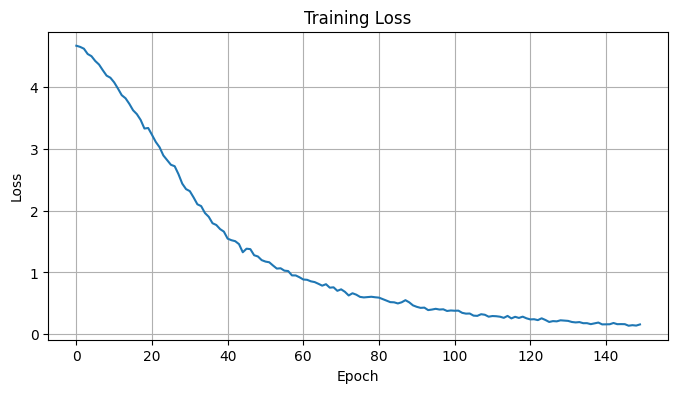

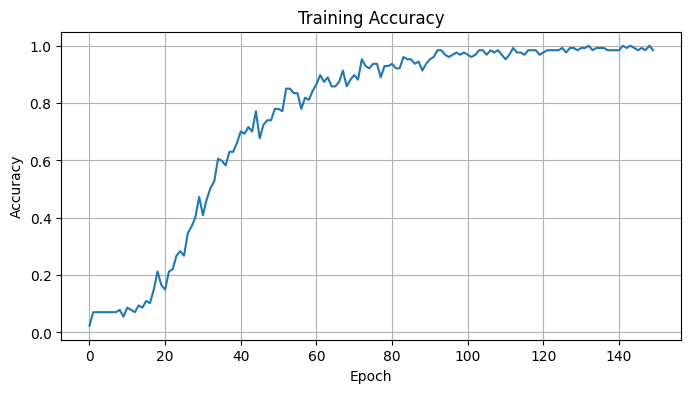

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'])
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


## 9. Generate text from seed prompts


In [9]:
index_to_word = {index: word for word, index in tokenizer.word_index.items()}

def generate_text(seed_text, next_words=20):
    output_text = seed_text.lower()
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([output_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding='pre')
        predicted_probs = model.predict(token_list, verbose=0)[0]
        predicted_index = np.argmax(predicted_probs)
        predicted_word = index_to_word.get(predicted_index, "")
        output_text += " " + predicted_word
    return output_text

prompts = [
    "artificial intelligence",
    "the future of technology",
    "writers used digital systems"
]

for prompt in prompts:
    print("\nSeed:", prompt)
    print("Generated:", generate_text(prompt, next_words=18))



Seed: artificial intelligence
Generated: artificial intelligence became a tool for writing learning planning and discovery discovery from of of documents documents sound sound sound

Seed: the future of technology
Generated: the future of technology depends not only on invention but also on responsibility fairness and trust trust trust trust trust sound sound

Seed: writers used digital systems
Generated: writers used digital systems to expand ideas improve drafts and explore new forms of creativity creativity creativity sound sound sound sound sound


## 10. Practical application demonstration

A simple use case is **content assistance**: the model can continue a writing prompt for a student, blogger, or analyst.


In [10]:
seed = "generative models can"
generated_text = generate_text(seed, next_words=20)

print("Application scenario: content creation assistant")
print("Prompt:", seed)
print("Output:", generated_text)


Application scenario: content creation assistant
Prompt: generative models can
Output: generative models can produce text by learning language patterns from large collections of documents documents documents documents sound sound sound sound sound sound


## 11. Discussion

### Why this is not a full GPT model
This notebook uses an **LSTM** for simplicity and speed.  
Real GPT systems use:
- Transformer decoder blocks
- Self-attention
- Positional encodings
- Massive pretraining datasets
- Next-token prediction at much larger scale

### Why this notebook is still useful
It clearly demonstrates the core generative idea:
**learn from text patterns -> predict the next token -> generate new sequences**


## 12. Ethical considerations

Generative AI provides useful capabilities, but also introduces risks:
- biased outputs
- misinformation
- plagiarism concerns
- unsafe or misleading generated content

Possible mitigations:
- dataset curation
- human review
- moderation filters
- transparency about AI-generated text


## 13. Conclusion

This notebook provides an accessible introduction to generative text modeling in Python.  
It supports the written report by showing a complete workflow:
1. dataset preparation
2. preprocessing
3. model training
4. text generation
5. interpretation of results
